# End-to-End EDA on Zomato Restaurant Reviews

## Loading Data and Initial Exploration

In [1]:
# Import Libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

In [2]:
# Load datasets
reviews_df = pd.read_csv('Zomato Restaurant reviews.csv')
metadata_df = pd.read_csv('Zomato Restaurant names and Metadata.csv')

print(f"reviews_df  -> {reviews_df.shape[0]} rows, {reviews_df.shape[1]} columns")
print(f"metadata_df -> {metadata_df.shape[0]} rows, {metadata_df.shape[1]} columns")

reviews_df  -> 10000 rows, 7 columns
metadata_df -> 105 rows, 6 columns


In [3]:
# Display first 5 rows of both datasets
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [4]:
metadata_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [5]:
# Data types, columns, shape
print("=== reviews_df.info() ===")
reviews_df.info()
print("\n=== metadata_df.info() ===")
metadata_df.info()

=== reviews_df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Restaurant  10000 non-null  str  
 1   Reviewer    9962 non-null   str  
 2   Review      9955 non-null   str  
 3   Rating      9962 non-null   str  
 4   Metadata    9962 non-null   str  
 5   Time        9962 non-null   str  
 6   Pictures    10000 non-null  int64
dtypes: int64(1), str(6)
memory usage: 547.0 KB

=== metadata_df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         105 non-null    str  
 1   Links        105 non-null    str  
 2   Cost         105 non-null    str  
 3   Collections  51 non-null     str  
 4   Cuisines     105 non-null    str  
 5   Timings      104 non-null    str  
dtypes: str(6)
memory usage: 5.1 KB


## Data Cleaning

### Missing Values

In [6]:
# Check for missing values
print("=== Missing values: reviews_df ===")
print(reviews_df.isnull().sum())
print("\n=== Missing values: metadata_df ===")
print(metadata_df.isnull().sum())

=== Missing values: reviews_df ===
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

=== Missing values: metadata_df ===
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64


In [7]:
# Handle missing values
# 38 rows in reviews_df are missing Reviewer/Review/Rating/Metadata/Time together -> these are
# fully blank review rows (no usable content), so they are dropped rather than imputed
blank_review_rows = reviews_df['Rating'].isnull().sum()
print(f"Fully blank review rows to drop: {blank_review_rows}")
reviews_df = reviews_df.dropna(subset=['Rating', 'Review']).reset_index(drop=True)

# metadata_df: Collections is an optional tag field (54/105 missing) -> fill with 'None Listed'
metadata_df['Collections'] = metadata_df['Collections'].fillna('None Listed')
# Timings: 1 missing -> fill with 'Not Available'
metadata_df['Timings'] = metadata_df['Timings'].fillna('Not Available')

print("\nRemaining nulls, reviews_df:\n", reviews_df.isnull().sum().sum())
print("Remaining nulls, metadata_df:\n", metadata_df.isnull().sum().sum())

Fully blank review rows to drop: 38

Remaining nulls, reviews_df:
 0
Remaining nulls, metadata_df:
 0


### Removing Duplicates

In [8]:
# Check for and remove duplicate rows
print(f"Duplicate rows in reviews_df: {reviews_df.duplicated().sum()}")
print(f"Duplicate rows in metadata_df: {metadata_df.duplicated().sum()}")

reviews_df.drop_duplicates(inplace=True)
metadata_df.drop_duplicates(inplace=True)
reviews_df.reset_index(drop=True, inplace=True)

print(f"\nShape after dedup -> reviews_df: {reviews_df.shape}, metadata_df: {metadata_df.shape}")

Duplicate rows in reviews_df: 0
Duplicate rows in metadata_df: 0

Shape after dedup -> reviews_df: (9955, 7), metadata_df: (105, 6)


### Correcting Data Types 

In [9]:
# Rating contains a non-numeric value ('Like') alongside numeric strings -> coerce to numeric,
# turning 'Like' into NaN, then drop those (a handful of rows with no real star rating)
reviews_df['Rating'] = pd.to_numeric(reviews_df['Rating'], errors='coerce')
print(f"Rows with non-numeric Rating ('Like', etc.): {reviews_df['Rating'].isnull().sum()}")
reviews_df = reviews_df.dropna(subset=['Rating']).reset_index(drop=True)

# Cost has thousands-separator commas as text (e.g. '1,300') -> strip commas, cast to numeric
metadata_df['Cost'] = metadata_df['Cost'].str.replace(',', '', regex=False).astype(float)

# Time -> proper datetime
reviews_df['Time'] = pd.to_datetime(reviews_df['Time'], format='%m/%d/%Y %H:%M')

# Parse the 'Metadata' text field ('3 Reviews , 2 Followers') into numeric reviewer stats
def extract_count(pattern, text):
    match = re.search(pattern, str(text))
    return int(match.group(1)) if match else 0

reviews_df['Reviewer_Review_Count'] = reviews_df['Metadata'].apply(
    lambda x: extract_count(r'(\d+)\s+Reviews?', x))
reviews_df['Reviewer_Follower_Count'] = reviews_df['Metadata'].apply(
    lambda x: extract_count(r'(\d+)\s+Followers?', x))

print(reviews_df.dtypes)
print()
print(metadata_df.dtypes)

Rows with non-numeric Rating ('Like', etc.): 1
Restaurant                            str
Reviewer                              str
Review                                str
Rating                            float64
Metadata                              str
Time                       datetime64[us]
Pictures                            int64
Reviewer_Review_Count               int64
Reviewer_Follower_Count             int64
dtype: object

Name               str
Links              str
Cost           float64
Collections        str
Cuisines           str
Timings            str
dtype: object


In [10]:
# Merge the two datasets on restaurant name for the analyses that need both (e.g. Cost vs Rating)
merged_df = reviews_df.merge(metadata_df, left_on='Restaurant', right_on='Name', how='left')
print(f"Merged shape: {merged_df.shape}")
print(f"Unmatched rows after merge: {merged_df['Name'].isnull().sum()}")
merged_df.head(3)

Merged shape: (9954, 15)
Unmatched rows after merge: 0


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Reviewer_Review_Count,Reviewer_Follower_Count,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",2019-05-25 15:54:00,0,1,2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",2019-05-25 14:20:00,0,3,2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",2019-05-24 22:54:00,0,2,3,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


## Exploratory Data Analysis

### Basic Statistics

In [11]:
# Summary statistics for numerical columns
reviews_df.describe()

,Rating,Time,Pictures,Reviewer_Review_Count,Reviewer_Follower_Count
count,9954.000000,9954,9954.000000,9954.000000,9954.000000
mean,3.600261,2018-11-29 12:08:33.514165,0.751959,23.961925,163.122363
min,1.000000,2016-05-31 16:41:00,0.000000,0.000000,0.000000
25%,3.000000,2018-08-12 00:06:45,0.000000,1.000000,1.000000
50%,4.000000,2018-12-24 00:09:30,0.000000,4.000000,7.000000
75%,5.000000,2019-03-31 19:20:45,0.000000,22.000000,63.000000
max,5.000000,2019-05-25 20:23:00,64.000000,1031.000000,13410.000000
std,1.483573,NaN,2.575819,50.606436,620.182806


In [12]:
metadata_df.describe()

,Cost
count,105.000000
mean,861.428571
std,510.149730
min,150.000000
25%,500.000000
50%,700.000000
75%,1200.000000
max,2800.000000


*** Insights ***

### Rating Distribution 

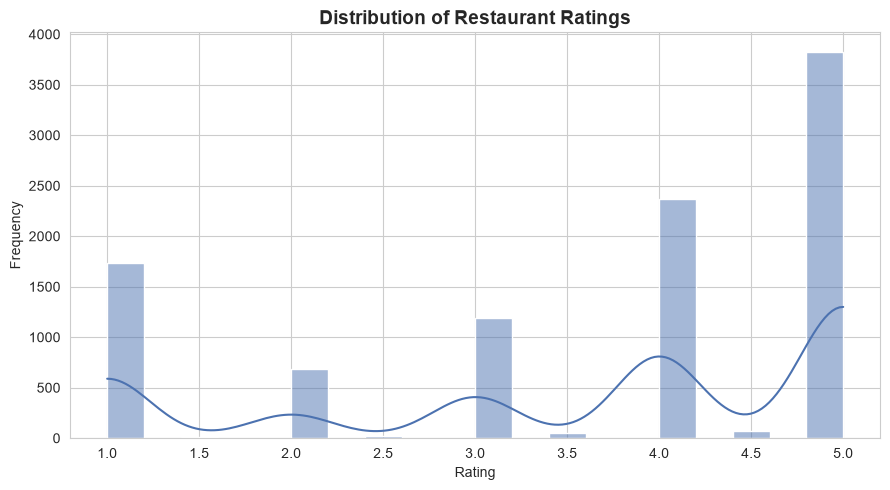

Rating
1.0    1735
1.5       9
2.0     684
2.5      19
3.0    1192
3.5      47
4.0    2373
4.5      69
5.0    3826
Name: count, dtype: int64


In [13]:
# Rating distribution
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(reviews_df['Rating'], kde=True, bins=20, color='#4C72B0', ax=ax)
ax.set_title('Distribution of Restaurant Ratings', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(reviews_df['Rating'].value_counts().sort_index())

*** Insights ***

### Top Raated Restaurants

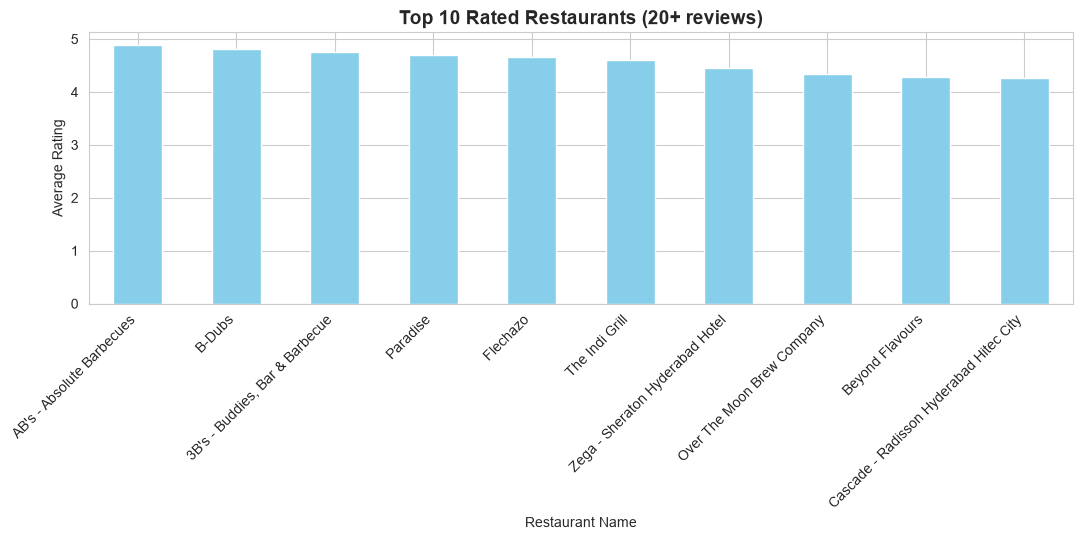

Restaurant
AB's - Absolute Barbecues                  4.88
B-Dubs                                     4.81
3B's - Buddies, Bar & Barbecue             4.76
Paradise                                   4.70
Flechazo                                   4.66
The Indi Grill                             4.60
Zega - Sheraton Hyderabad Hotel            4.45
Over The Moon Brew Company                 4.34
Beyond Flavours                            4.28
Cascade - Radisson Hyderabad Hitec City    4.26
Name: Rating, dtype: float64

In [14]:
# Top 10 rated restaurants based on average rating (restricted to restaurants with a
# meaningful number of reviews, so a single 5-star review doesn't misleadingly top the list)
review_counts_per_restaurant = reviews_df['Restaurant'].value_counts()
eligible_restaurants = review_counts_per_restaurant[review_counts_per_restaurant >= 20].index

top_rated = (reviews_df[reviews_df['Restaurant'].isin(eligible_restaurants)]
             .groupby('Restaurant')['Rating']
             .mean()
             .sort_values(ascending=False)
             .head(10))

fig, ax = plt.subplots(figsize=(11, 5.5))
top_rated.plot(kind='bar', color='skyblue', ax=ax)
ax.set_title('Top 10 Rated Restaurants (20+ reviews)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Rating')
ax.set_xlabel('Restaurant Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_rated.round(2)

### Cuisine Distribution

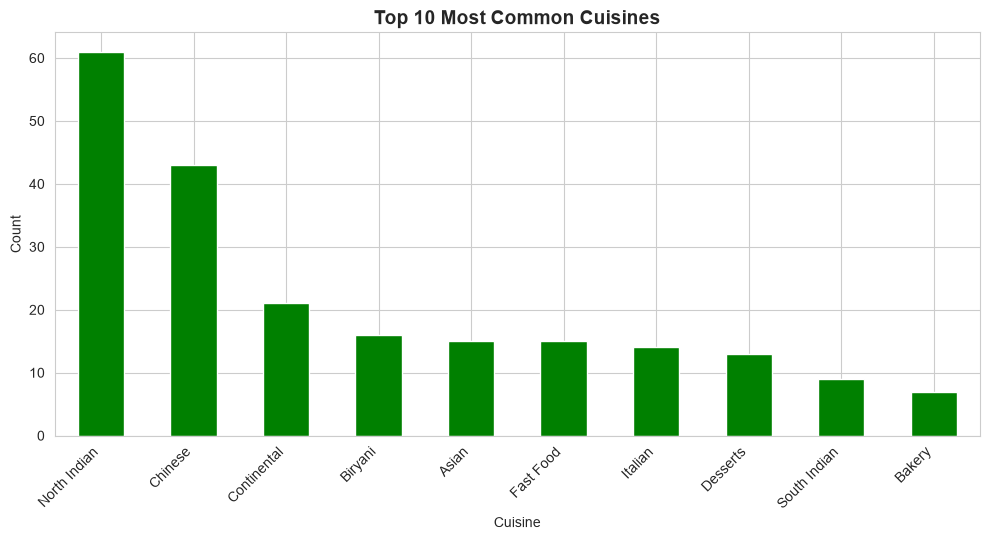

Cuisines
North Indian    61
Chinese         43
Continental     21
Biryani         16
Asian           15
Fast Food       15
Italian         14
Desserts        13
South Indian     9
Bakery           7
Name: count, dtype: int64

In [15]:
# metadata_df's actual column is 'Cuisines' (plural) and each restaurant lists multiple
# comma-separated cuisines -> split and count each cuisine individually
cuisines_split = metadata_df['Cuisines'].str.split(',').explode().str.strip()
cuisine_count = cuisines_split.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
cuisine_count.plot(kind='bar', color='green', ax=ax)
ax.set_title('Top 10 Most Common Cuisines', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Cuisine')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

cuisine_count

***Insights***

### Location Distribution

Distinct localities implied by restaurant links:
Links
hyderabad             104
thetiltbarrepublic      1
Name: count, dtype: int64


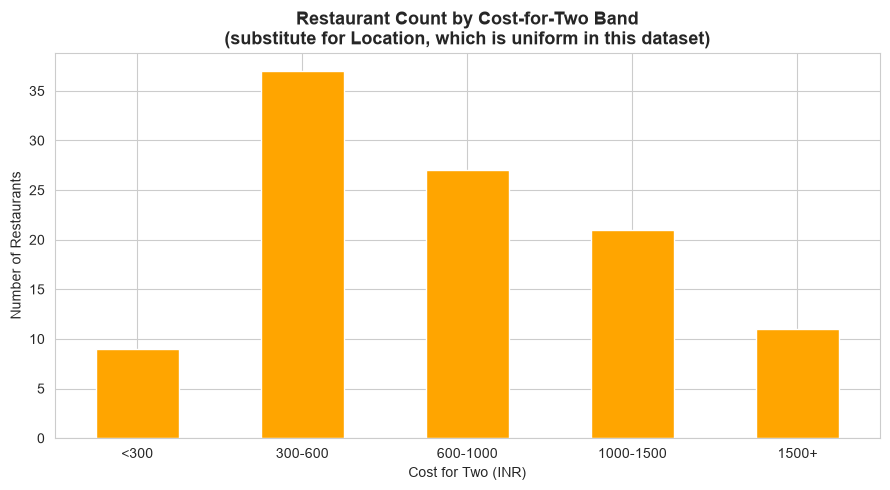

cost_band
<300          9
300-600      37
600-1000     27
1000-1500    21
1500+        11
Name: count, dtype: int64

In [16]:
# NOTE: metadata_df has no 'Location' column, and every restaurant's Zomato link resolves to
# the same locality (Gachibowli, Hyderabad) -- so a literal location-distribution chart would
# just be one bar at 100%. As a meaningful substitute restaurant-level grouping, this section
# instead looks at the distribution of Cost-for-two price bands across restaurants.
locality_check = metadata_df['Links'].str.split('/').str[3].value_counts()
print("Distinct localities implied by restaurant links:")
print(locality_check)

cost_bins = [0, 300, 600, 1000, 1500, 3000]
cost_labels = ['<300', '300-600', '600-1000', '1000-1500', '1500+']
metadata_df['cost_band'] = pd.cut(metadata_df['Cost'], bins=cost_bins, labels=cost_labels)
cost_band_count = metadata_df['cost_band'].value_counts().reindex(cost_labels)

fig, ax = plt.subplots(figsize=(9, 5))
cost_band_count.plot(kind='bar', color='orange', ax=ax)
ax.set_title('Restaurant Count by Cost-for-Two Band\n(substitute for Location, which is uniform in this dataset)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Restaurants')
ax.set_xlabel('Cost for Two (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cost_band_count

***Insights***

### Correlation Analysis

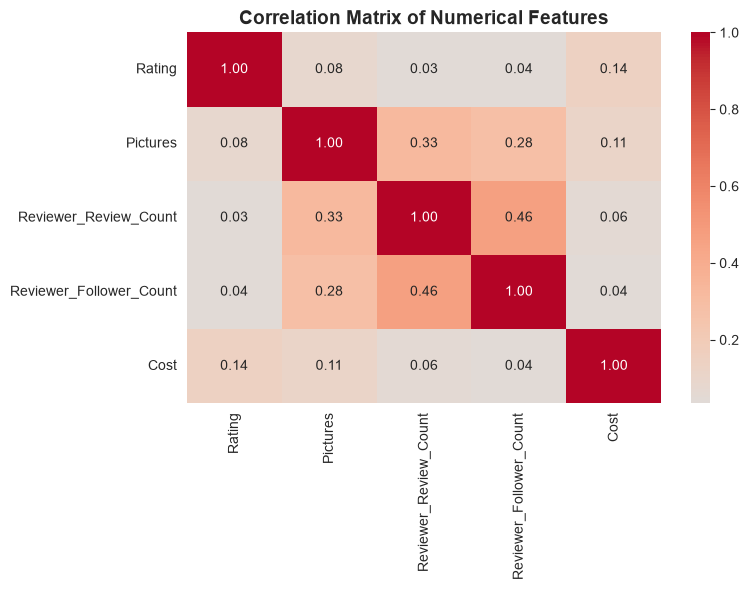

Rating                     1.000000
Cost                       0.144119
Pictures                   0.082834
Reviewer_Follower_Count    0.035638
Reviewer_Review_Count      0.034765
Name: Rating, dtype: float64

In [17]:
# Correlation between numerical features: Rating, Pictures, reviewer credibility, and Cost
numeric_cols = ['Rating', 'Pictures', 'Reviewer_Review_Count', 'Reviewer_Follower_Count', 'Cost']
correlation = merged_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

correlation['Rating'].sort_values(ascending=False)

***Insights***

### Price (Cost) vs. Rating

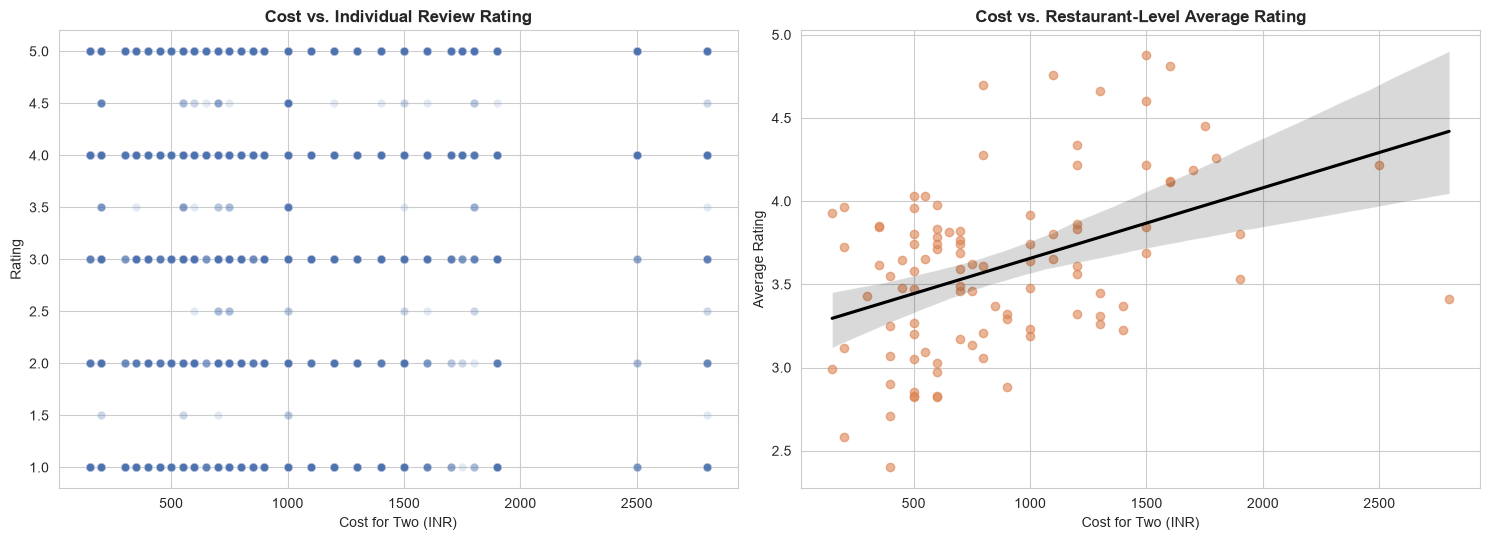

Correlation (Cost, restaurant avg rating): 0.422


In [18]:
# metadata_df has a Cost column (cost for two) -> analyze its relationship with rating
# using the restaurant-level average rating for a cleaner view than the noisier review-level scatter
restaurant_avg_rating = reviews_df.groupby('Restaurant')['Rating'].mean().reset_index()
restaurant_avg_rating = restaurant_avg_rating.merge(
    metadata_df[['Name', 'Cost']], left_on='Restaurant', right_on='Name', how='left')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(x='Cost', y='Rating', data=merged_df, alpha=0.15, ax=axes[0], color='#4C72B0')
axes[0].set_title('Cost vs. Individual Review Rating', fontweight='bold')
axes[0].set_xlabel('Cost for Two (INR)')
axes[0].set_ylabel('Rating')

sns.regplot(x='Cost', y='Rating', data=restaurant_avg_rating, ax=axes[1],
            scatter_kws={'alpha': 0.6, 'color': '#DD8452'}, line_kws={'color': 'black'})
axes[1].set_title('Cost vs. Restaurant-Level Average Rating', fontweight='bold')
axes[1].set_xlabel('Cost for Two (INR)')
axes[1].set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

print("Correlation (Cost, restaurant avg rating):",
      round(restaurant_avg_rating['Cost'].corr(restaurant_avg_rating['Rating']), 3))

***Insights**

## Sentimental Analysis

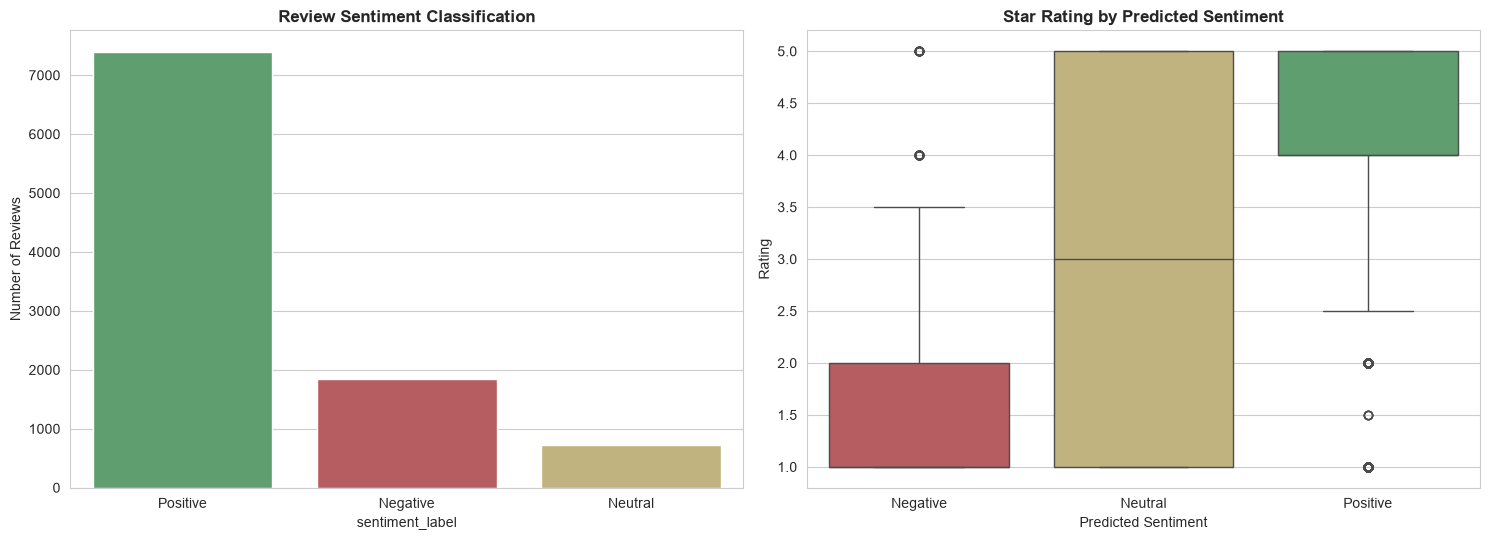

sentiment_label
Positive    7390
Negative    1847
Neutral      717
Name: count, dtype: int64

sentiment_label
Negative    1.57
Neutral     2.98
Positive    4.17
Name: Rating, dtype: float64


In [ ]:
# VADER is well suited to short, informal review text (handles punctuation/emphasis/negation)
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['sentiment_score'] = reviews_df['Review'].apply(
    lambda t: analyzer.polarity_scores(str(t))['compound'])
reviews_df['sentiment_label'] = reviews_df['sentiment_score'].apply(get_sentiment)

sentiment_counts = reviews_df['sentiment_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, hue=sentiment_counts.index,
            palette={'Positive': '#55A868', 'Neutral': '#CCB974', 'Negative': '#C44E52'},
            legend=False, ax=axes[0])
axes[0].set_title('Review Sentiment Classification', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')

sns.boxplot(x='sentiment_label', y='Rating', data=reviews_df,
            order=['Negative', 'Neutral', 'Positive'],
            hue='sentiment_label',
            palette={'Positive': '#55A868', 'Neutral': '#CCB974', 'Negative': '#C44E52'},
            legend=False, ax=axes[1])
axes[1].set_title('Star Rating by Predicted Sentiment', fontweight='bold')
axes[1].set_xlabel('Predicted Sentiment')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

print(sentiment_counts)ß
print()
print(reviews_df.groupby('sentiment_label')['Rating'].mean().round(2))

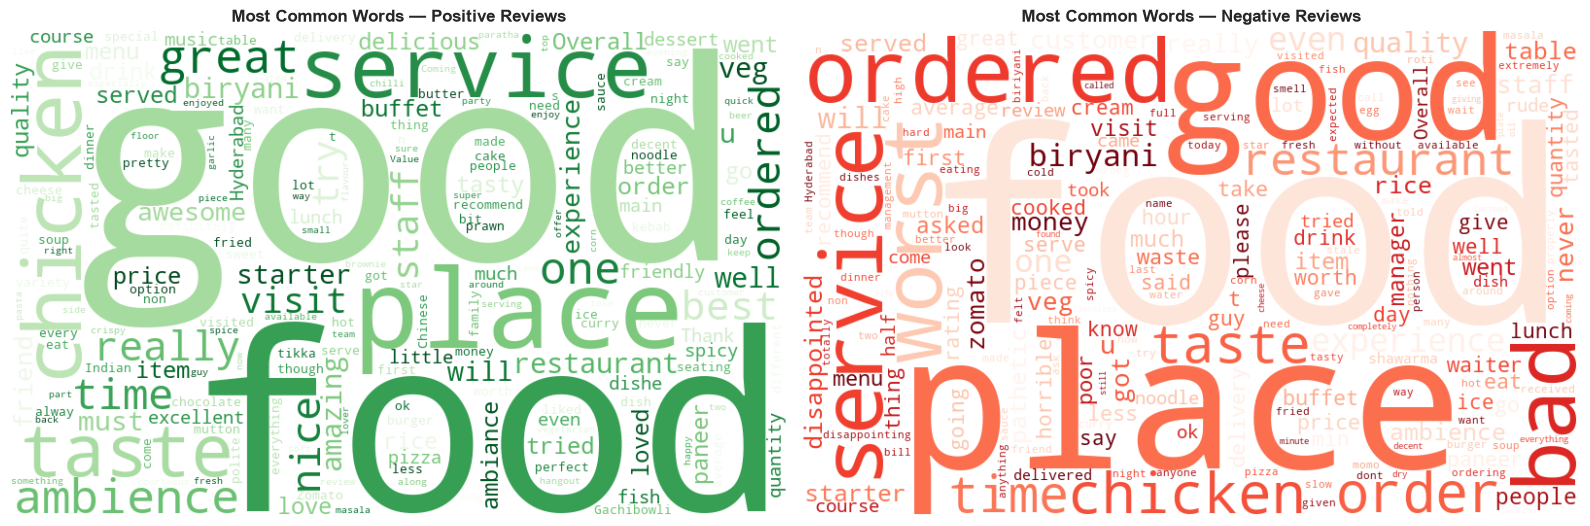

In [20]:
# Word clouds for positive vs negative reviews
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

positive_text = ' '.join(reviews_df[reviews_df['sentiment_label'] == 'Positive']['Review'].astype(str))
negative_text = ' '.join(reviews_df[reviews_df['sentiment_label'] == 'Negative']['Review'].astype(str))

wc_pos = WordCloud(width=800, height=500, background_color='white', colormap='Greens',
                    collocations=False).generate(positive_text)
wc_neg = WordCloud(width=800, height=500, background_color='white', colormap='Reds',
                    collocations=False).generate(negative_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common Words — Positive Reviews', fontweight='bold')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Common Words — Negative Reviews', fontweight='bold')

plt.tight_layout()
plt.show()

***Insights***